# Exploratory Data Analysis

Before building any machine learning model, it is essential to understand the dataset. Exploratory Data Analysis (EDA) helps us inspect the available features, identify data quality issues, understand the distribution of the variables, and investigate which passenger characteristics appear to be associated with survival.

In this notebook we will:

* Load the training and test datasets.
* Inspect their structure and contents.
* Examine missing values and data types.
* Explore the distribution of the target variable.
* Analyze the relationship between passenger attributes and survival.
* Identify potential opportunities for feature engineering in the next stage.

By the end of this notebook, we should have a solid understanding of the data and a clear plan for preparing it for machine learning models.


## Dataset Description

The training dataset contains one row per passenger and the following variables:

| Feature    | Description                                                                                                                                    |
| ---------- | ---------------------------------------------------------------------------------------------------------------------------------------------- |
| `Survived` | Target variable. `0` indicates the passenger did not survive, while `1` indicates survival. This column is only available in the training set. |
| `Pclass`   | Passenger ticket class (`1` = First, `2` = Second, `3` = Third).                                                                               |
| `Name`     | Passenger's full name.                                                                                                                         |
| `Sex`      | Passenger's sex (`male` or `female`).                                                                                                          |
| `Age`      | Passenger's age in years. Fractional values represent infants, while values ending in `.5` correspond to estimated ages.                       |
| `SibSp`    | Number of siblings and spouses aboard the Titanic.                                                                                             |
| `Parch`    | Number of parents and children aboard the Titanic. Children traveling only with a nanny have `Parch = 0`.                                      |
| `Ticket`   | Ticket number.                                                                                                                                 |
| `Fare`     | Passenger fare.                                                                                                                                |
| `Cabin`    | Cabin identifier. Many values are missing.                                                                                                     |
| `Embarked` | Port of embarkation (`C` = Cherbourg, `Q` = Queenstown, `S` = Southampton).                                                                    |

The `SibSp` and `Parch` variables deserve a brief clarification. In the context of this dataset:

* `Sibling` includes brother, sister, stepbrother, and stepsister.
* `Spouse` includes husband and wife (fiancés and mistresses are not considered).
* `Parent` includes mother and father.
* `Child` includes daughter, son, stepdaughter, and stepson.

## Imports

First, we import the libraries used throughout the analysis.

In [15]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

## Loading the Data

The dataset is split into a training set and a test set. The training data includes the target variable (`Survived`), which we aim to predict, while the test set contains only the input features and is used for final Kaggle submission.

We begin by loading both datasets and performing an initial inspection. This includes checking dataset dimensions, verifying consistency of feature names across train and test sets, and looking for potential issues such as duplicated rows or obvious structural inconsistencies.

In [16]:
df_test = pd.read_csv("data/test.csv")
df_train = pd.read_csv("data/train.csv")

print(
f"""
--------------------
Train set:

{df_train.shape[0]} rows
{df_train.duplicated().sum()} duplicated rows
{df_train.shape[1]} columns
--------------------
Test set:

{df_test.shape[0]} rows
{df_test.duplicated().sum()} duplicated rows
{df_test.shape[1]} columns
--------------------
Columns train/test:
{[column for column in df_train.columns if column in df_test.columns]}

Target variable (only in test):
{[column for column in df_train.columns if column not in df_test.columns]}
--------------------
"""
)


--------------------
Train set:

891 rows
0 duplicated rows
12 columns
--------------------
Test set:

418 rows
0 duplicated rows
11 columns
--------------------
Columns train/test:
['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Target variable (only in test):
['Survived']
--------------------



In [17]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [18]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [19]:
# All features minus the tareget
features = [column for column in df_test.columns if column not in ("PassengerId", "Survived")]

# feature description dataframe
df_features = pd.DataFrame({
    "Name": features,
    "Type": ["numerical" if pd.api.types.is_numeric_dtype(df_test[column]) else "categorical" for column in features],
    "Category":["original"]*len(features),
    "Source":features,
})

feature_to_description = {
    "Survived": "Target variable. `0` indicates the passenger did not survive, while `1` indicates survival. This column is only available in the training set.",
    "Pclass": "Passenger ticket class (`1` = First, `2` = Second, `3` = Third).",
    "Name": "Passenger's full name.",
    "Sex": "Passenger's sex (`male` or `female`).",
    "Age": "Passenger's age in years. Fractional values represent infants, while values ending in `.5` correspond to estimated ages.",
    "SibSp": "Number of siblings and spouses aboard the Titanic.",
    "Parch": "Number of parents and children aboard the Titanic. Children traveling only with a nanny have `Parch = 0`.",
    "Ticket": "Ticket number.",
    "Fare": "Passenger fare.",
    "Cabin": "Cabin identifier. Many values are missing.",
    "Embarked": "Port of embarkation (`C` = Cherbourg, `Q` = Queenstown, `S` = Southampton).",
}

df_features["Description"] = df_features["Name"].map(feature_to_description)

df_features

,Name,Type,Category,Source,Description
0,Pclass,numerical,original,Pclass,"Passenger ticket class (`1` = First, `2` = Sec..."
1,Name,categorical,original,Name,Passenger's full name.
2,Sex,categorical,original,Sex,Passenger's sex (`male` or `female`).
3,Age,numerical,original,Age,Passenger's age in years. Fractional values re...
4,SibSp,numerical,original,SibSp,Number of siblings and spouses aboard the Tita...
5,Parch,numerical,original,Parch,Number of parents and children aboard the Tita...
6,Ticket,categorical,original,Ticket,Ticket number.
7,Fare,numerical,original,Fare,Passenger fare.
8,Cabin,categorical,original,Cabin,Cabin identifier. Many values are missing.
9,Embarked,categorical,original,Embarked,"Port of embarkation (`C` = Cherbourg, `Q` = Qu..."


In [20]:
# Train/Test split
df_train["IsTrainSet"] = True
df_test["IsTrainSet"] = False

df_full = pd.concat(
    [df_train, df_test],
    axis=0,
    ignore_index=True
)

print(
    f"""
    Full dataset ( train + test ):

    {df_full.shape[0]} rows
    {df_full.duplicated().sum()} duplicated rows
    {df_full.shape[1]} columns
    """
)

df_full


    Full dataset ( train + test ):

    1309 rows
    0 duplicated rows
    13 columns
    


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,IsTrainSet
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,True
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,True
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,True
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,True
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,False
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,False
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,False
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,False


In order to start getting a feel for the data we have in our hands, we can use `info()` and `describe()` to learn about data types, missing data, and overall statistical metrics such as mean, median, max, min etc.

In [21]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
 12  IsTrainSet   1309 non-null   bool   
dtypes: bool(1), float64(3), int64(4), object(5)
memory usage: 124.1+ KB


In [22]:
df_full.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


## Missing values

I always like to visually inspect how much of the data is missing before proceeding with the analysis.

Text(0.5, 1.0, 'Missing values heatmap')

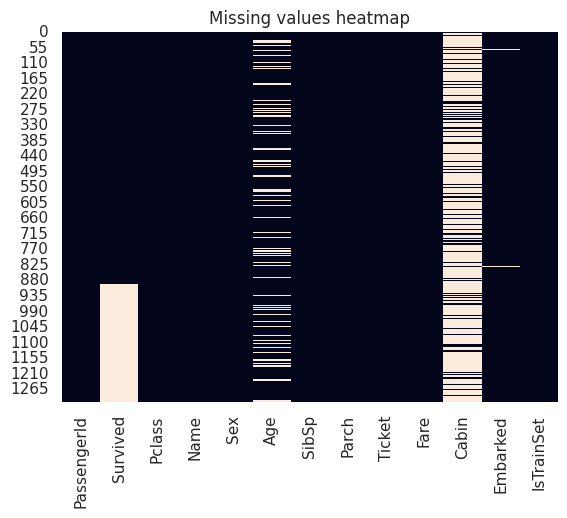

In [23]:
sns.heatmap(df_full.isnull(), cbar = False).set_title("Missing values heatmap")





## Summary statistics

## Target variable

## Univariate analysis

## Bivariate analysis

## Correlation analysis

## Initial conclusions